In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)

def setup_screen(w=640, h=480):
    plt.rcParams["figure.figsize"] = (10, int(10*(h*1.0/w)))
    fig, ax = plt.subplots(1, 1)
    ax.set_xlim([0, w])
    ax.set_ylim([0, h])
    # ax.grid()
    ax.grid(which='major', color='#CCCCCC', linestyle='--')
    ax.grid(which='minor', color='#CCCCCC', linestyle=':')
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    return ax

def show_screen():
  plt.show()


def draw_polygon(screen,
                   xy, # array of point (x1, y1),... (xn, yn) # 2xn
                   color ='blue'
                   ):
  x = xy[0,:]
  y = xy[1,:]
  screen.plot(x, y, color)
  screen.plot([x[-1], x[0]], [y[-1], y[0]], color)

## Setup
w, h = 640, 480

### Fixed Setup
 - Screen size width=640, height=480
 - Draw a blue square at center screen with each size: 2*d (where d = 20)
 - Function draw **draw_polygon()**: draw polygon where xy is numpy array size 2xn

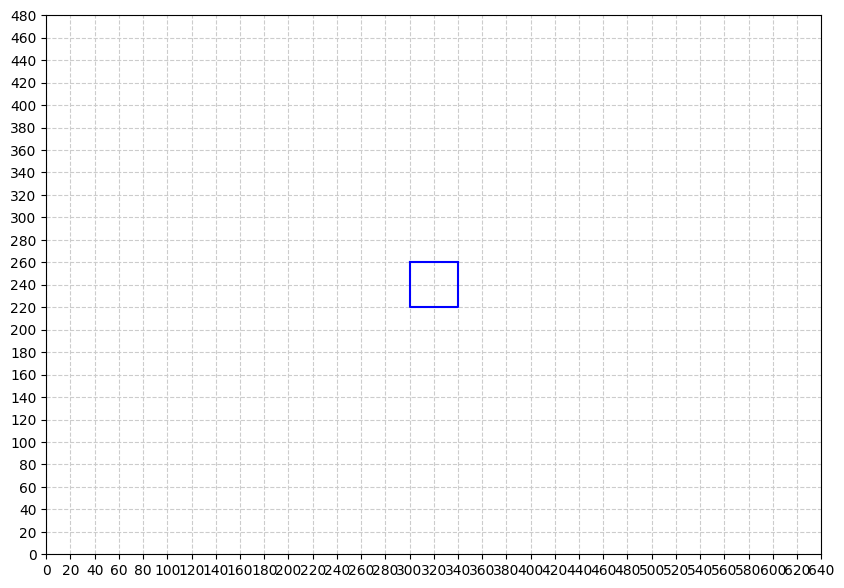

In [2]:
screen = setup_screen(w, h) # Create a new screen
cx, cy = w/2, h/2
d = 20
x1, y1 = cx-d, cy+d
x2, y2 = cx+d, cy-d
xy = np.array([[x1, x1,  x2, x2], [y1, y2, y2, y1]])
draw_polygon(screen, xy)
show_screen()   # Show screen

### **Task 01** (60 pt)
 - Find 2D homogeneous Transformation (3x3 matrix) blue shape (rectangle) into red diamond
 - Draw both shapes (as shown below)

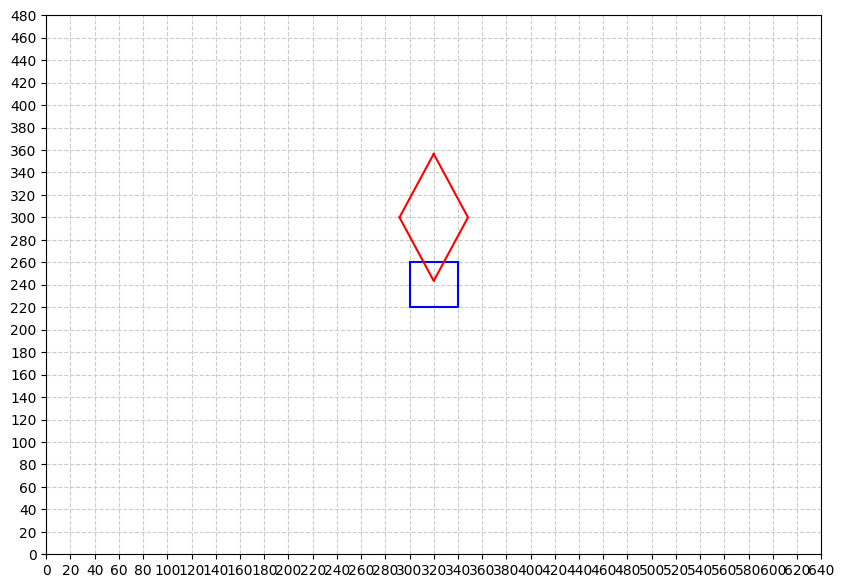

In [3]:
#Name: Mary-Rose Tracy 
#ID:1001852753
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
def setup_screen(w=640,h=480):
    plt.rcParams["figure.figsize"]=(10,int(10*(h*1.0/w)))
    fig,ax=plt.subplots(1, 1)
    ax.set_xlim([0,w])
    ax.set_ylim([0,h])
    ax.grid(which='major',color='#CCCCCC',linestyle='--')
    ax.grid(which='minor',color='#CCCCCC',linestyle=':')
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    return ax
def draw_polygon(screen,xy,color='blue'):
    x=xy[0,:]
    y=xy[1,:]
    screen.plot(x,y,color)
    screen.plot([x[-1],x[0]],[y[-1],y[0]],color)
def show_screen():
    plt.show()
#FROM ^ previous infor
def HomoTransApply(xy,matrix):
    HomogenXY=np.vstack((xy,np.ones((1,xy.shape[1]))))
    TransF=np.dot(matrix, HomogenXY)
    return TransF[:2,:]
w,h=640,480 #the main deal
cx,cy=w/2,h/2
d=20
SquareXY=np.array([[cx-d,cx-d,cx+d,cx+d],
                      [cy+d,cy-d,cy-d,cy+d]])
#need to get the blue square
Mat1Homogen=np.array([
    [0.70710678,-0.70710678,263.43145751],
    [1.41421356,1.41421356,-491.95959493],
    [0,0,1] ])
DiaXY=HomoTransApply(SquareXY,Mat1Homogen)
screen=setup_screen(w,h) #plot shapes 
draw_polygon(screen,SquareXY,color='blue') 
draw_polygon(screen,DiaXY,color='red')
#blue square & diamond
show_screen()

### **Task 02** (40 pt)
- Find the rest of the homogeneous transformations (7 more) that rotate the red diamonds around the center screen as shown below.
- Note that your homogeneous matrices are not necessarily the same as the output, but being closer to them is better since we use a fixed setup.
- Draw all shapes (blue rectangle, 8 red diamonds, as shown below)

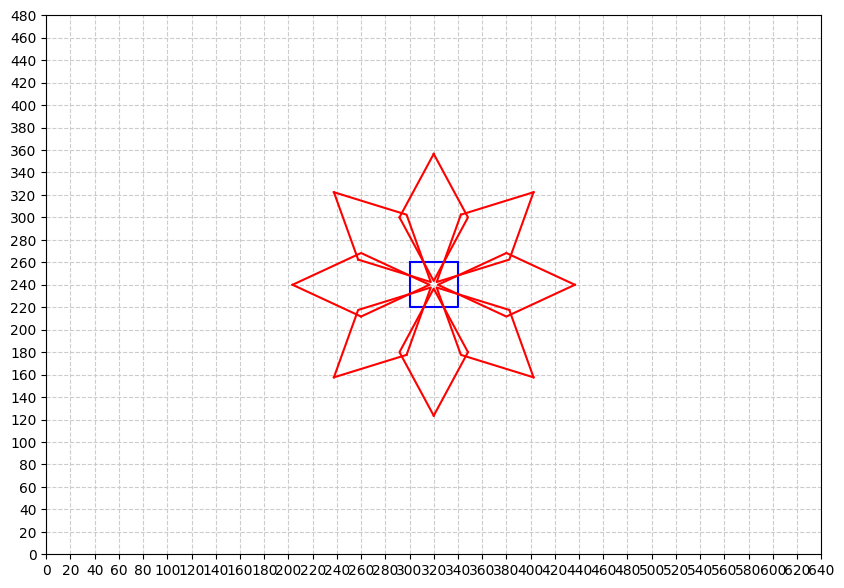

In [5]:
#Name: Mary-Rose Tracy 
#ID:1001852753
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
def setup_screen(w=640,h=480):
    plt.rcParams["figure.figsize"]=(10,int(10*(h*1.0/w)))
    fig,ax=plt.subplots(1,1)
    ax.set_xlim([0,w])
    ax.set_ylim([0,h])
    ax.grid(which='major',color='#CCCCCC',linestyle='--')
    ax.grid(which='minor',color='#CCCCCC',linestyle=':')
    ax.xaxis.set_major_locator(MultipleLocator(20))
    ax.yaxis.set_major_locator(MultipleLocator(20))
    return ax
def draw_polygon(screen,xy,color='blue'):
    x=xy[0,:]
    y=xy[1,:]
    screen.plot(x,y,color)
    screen.plot([x[-1],x[0]],[y[-1],y[0]],color)
def show_screen():
    plt.show()
def HomoTransApply(xy,matrix):
#FROM ^ previous infor
    HomogenXY=np.vstack((xy,np.ones((1,xy.shape[1]))))
    TransF=np.dot(matrix,HomogenXY)
    return TransF[:2,:]
def MatRorat(AngL,XCentr,YCentr):
    rad=np.radians(AngL) #Rhomogeneous rotation mat= rotates (XCentr, YCentr)
    ACos,ASin=np.cos(rad),np.sin(rad)
    return np.array([[ACos,-ASin,XCentr-XCentr*ACos+YCentr*ASin],
        [ASin,ACos,YCentr-XCentr*ASin-YCentr*ACos],
        [0,0,1]])
w,h=640,480
cx,cy=w/2,h/2
d=20
SquareXY=np.array([
    [cx-d,cx-d,cx+d,cx+d],
    [cy+d,cy-d,cy-d,cy+d]])
# Original Diamond Coordinates (From Task 01)
Mat1Homogen=np.array([
    [0.70710678,-0.70710678,263.43145751],
    [1.41421356,1.41421356,-491.95959493],
    [0,0,1]])
DiaXY=HomoTransApply(SquareXY,Mat1Homogen)
screen=setup_screen(w,h)
draw_polygon(screen,SquareXY,color='blue') 
for i in range(8):
    AngL=45*i
    matrix=MatRorat(AngL,cx,cy)
    DiamdRotat=HomoTransApply(DiaXY,matrix)
    draw_polygon(screen,DiamdRotat,color='red')
show_screen()
#need to get roation of 45 deg